In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import statsmodels as sm
from scipy import stats

### 1️⃣ Chargement des données

In [ ]:
df=pd.read_csv('Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [7]:
df.shape

(300153, 12)

In [8]:
df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

In [9]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [10]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [13]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### 2️⃣ Analyse technique des variables

**- Identification des variables : discrète et continue**

airline -----> variable catégorielle normale discrète

flight -----> variable catégorielle ordinale discrète

source_city ----->  variable catégorielle normale discrète

departure_time -----> variable catégorielle ordinale discrète

stops -----> variable catégorielle ordinale discrète

arrival_time -----> variable catégorielle ordinale discrète

destination_city -----> variable catégorielle normale discrète

class -----> variable catégorielle ordinale discrète

days_left -----> variable quantitative discrète

duration -----> variable quantitative continue

price ----->  variable quantitative continue


**- Vérifier les types de données**

In [14]:
df.dtypes

Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

### 3️⃣ Analyse univariée

#### Analyse univariée pour variable discrète

In [15]:
def analyse_discrete(df, col):

    print(f"--- Analyse de la variable : {col} ---")
    
    # 1. Calcul des fréquences
    counts = df[col].value_counts()
    n_modalites = len(counts)
    
    # Sécurité Top 20
    if n_modalites > 20:
        print(f"Attention : {n_modalites} modalités détectées. Affichage du Top 20 uniquement.")
        counts = counts.head(20)
        titre_suffixe = "(Top 20)"
    else:
        titre_suffixe = ""

    # Affichage statistiques en texte
    percent = (counts / len(df) * 100).round(2)
    df_stats = pd.DataFrame({'Nombre': counts, 'Pourcentage (%)': percent})
    print(df_stats)
    print("-" * 30)

    # 2. Visualisation
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Barplot 
    sns.barplot(
        x=counts.index, 
        y=counts.values, 
        ax=ax[0], 
        palette='viridis', 
        hue=counts.index,  # On lie la couleur aux labels
        legend=False       # On retire la légende car elle est redondante avec l'axe X
    )
    ax[0].set_title(f"Répartition de {col} {titre_suffixe}")
    ax[0].tick_params(axis='x', rotation=45)
    ax[0].set_ylabel("Nombre d'occurrences")

    # Pie Chart
    ax[1].pie(
        counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('viridis', n_colors=len(counts))
    )
    ax[1].set_title(f"Proportions de {col} {titre_suffixe}")

    plt.tight_layout()
    plt.show()

# # Variables a exécuter :
# analyse_discrete(df, 'flight')
# analyse_discrete(df, 'source_city')
# analyse_discrete(df, 'departure_time')
# analyse_discrete(df, 'stops')
# analyse_discrete(df, 'arrival_time')
# analyse_discrete(df, 'class')
# analyse_discrete(df, 'days_left')


--- Analyse de la variable : airline ---
           Nombre  Pourcentage (%)
airline                           
Vistara    127859            42.60
Air_India   80892            26.95
Indigo      43120            14.37
GO_FIRST    23173             7.72
AirAsia     16098             5.36
SpiceJet     9011             3.00
------------------------------


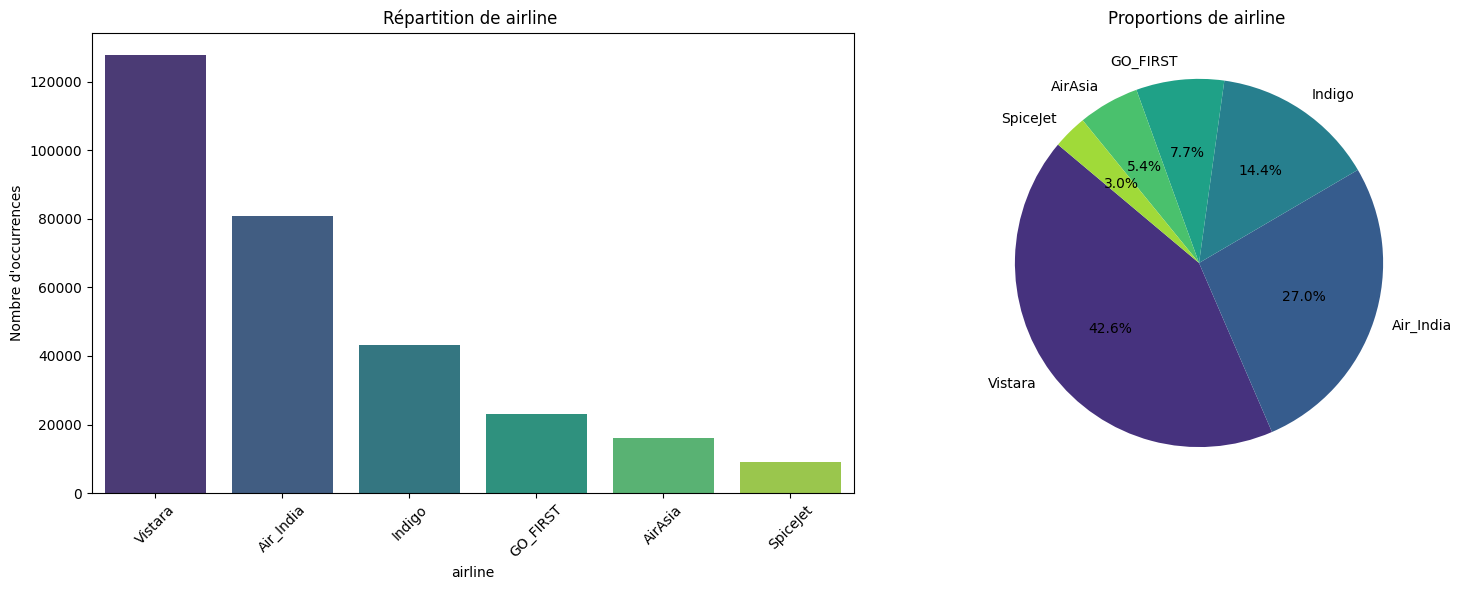

Interprétation: 
La compagnie aérienne (Vistara) est la domminante avec le plus grand nombre de billet, suivi de (Air_India). 


In [16]:
analyse_discrete(df, 'airline')
print('Interprétation: \nLa compagnie aérienne (Vistara) est la domminante avec le plus grand nombre de billet, suivi de (Air_India). ')

--- Analyse de la variable : destination_city ---
                  Nombre  Pourcentage (%)
destination_city                         
Mumbai             59097            19.69
Delhi              57360            19.11
Bangalore          51068            17.01
Kolkata            49534            16.50
Hyderabad          42726            14.23
Chennai            40368            13.45
------------------------------


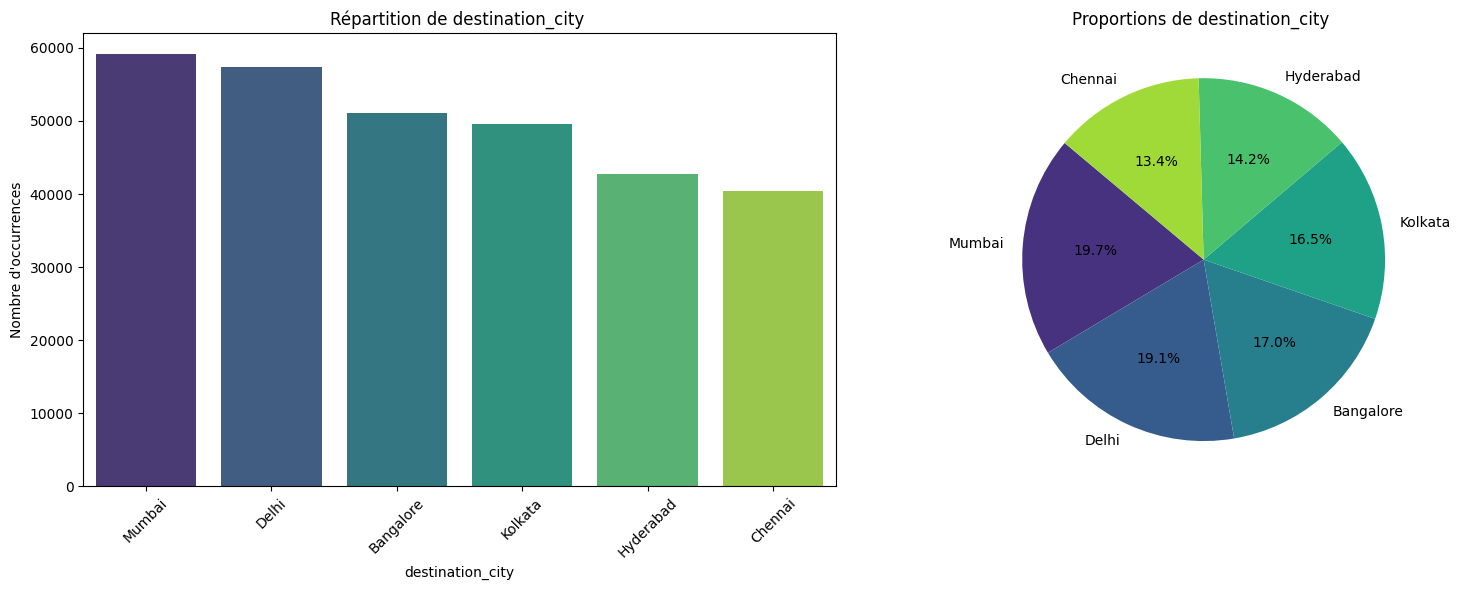

Interprétation: 
 Les destinations les plus demandé sans Mumbai(19.69%) et Delhi(19.11%)


In [17]:
analyse_discrete(df, 'destination_city')
print('Interprétation: \n Les destinations les plus demandé sans Mumbai(19.69%) et Delhi(19.11%)')

#### Analyse univariée pour variable continue (Statistiques + Distribution)

In [18]:
def analyse_continue(df, col):
   
    print(f"--- Analyse de la variable : {col} ---")
    
    # Statistiques descriptives
    display(df[col].describe())
    print("-" * 30)

    # Figure avec Boxplot en haut et Hist en bas
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 7))
 
    sns.boxplot(x=df[col], ax=ax_box, color="#D4434A") 
    ax_box.set(xlabel='', title=f"Distribution et Outliers de {col}")

    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color="skyblue")
    ax_hist.set_ylabel("Densité / Fréquence")

    plt.tight_layout()
    plt.show()

# Variables a exécuter :

--- Analyse de la variable : duration ---


count    300153.000000
mean         12.221021
std           7.191997
min           0.830000
25%           6.830000
50%          11.250000
75%          16.170000
max          49.830000
Name: duration, dtype: float64

------------------------------


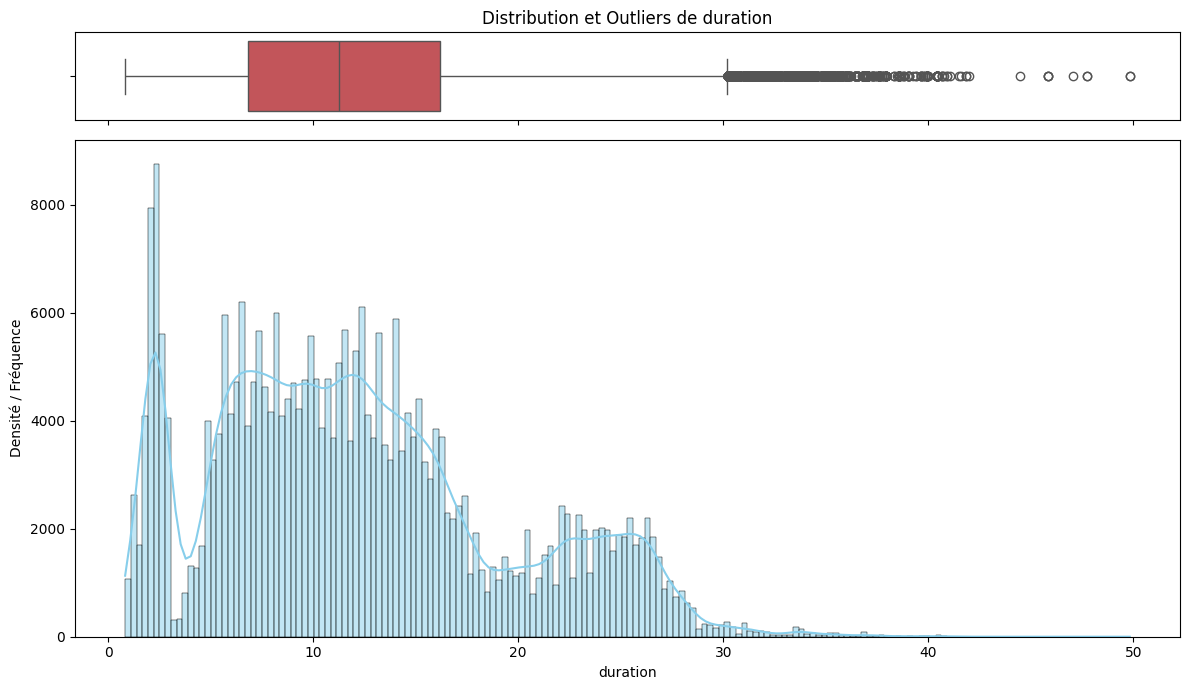

Interprétation: 
La durée n'est pas seulement liée à la distance, mais surtout au nombre d'escales. Un vol court est souvent direct, un vol long (> 10h) implique presque toujours des arrêts. 
La distribution est fortement asymétrique, avec une majorité de vols courts (1-3h) et une longue traîne de vols très longs (20-40h) qui sont des exceptions.


In [19]:
analyse_continue(df, 'duration')
print(f"Interprétation: \nLa durée n'est pas seulement liée à la distance, mais surtout au nombre d'escales. Un vol court est souvent direct, un vol long (> 10h) implique presque toujours des arrêts. \nLa distribution est fortement asymétrique, avec une majorité de vols courts (1-3h) et une longue traîne de vols très longs (20-40h) qui sont des exceptions.")

--- Analyse de la variable : price ---


count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

------------------------------


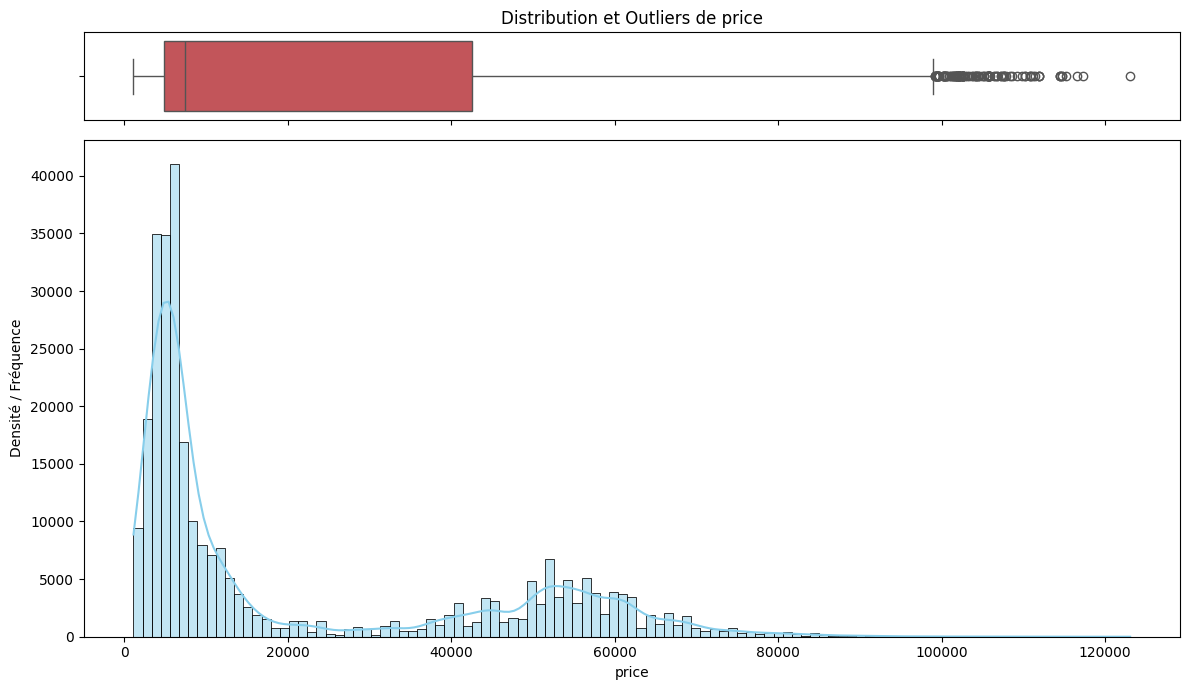

 Interprétation: 
 Bimodalité : La distribution présente deux sommets distincts, ce qui confirme une séparation radicale entre les tarifs Économie (bas prix) et Business (prix élevés).
 Dispersion : L'écart-type est très élevé (le prix varie de 1 100 à 120 000+). Cela indique que le modèle devra gérer des échelles de prix très différentes.
 Asymétrie : La queue de distribution s'étire vers la droite, montrant que les billets très chers (dernière minute) sont des exceptions qui tirent la moyenne vers le haut.


In [20]:
analyse_continue(df, 'price')

print(f" Interprétation: \n Bimodalité : La distribution présente deux sommets distincts, ce qui confirme une séparation radicale entre les tarifs Économie (bas prix) et Business (prix élevés).\n Dispersion : L'écart-type est très élevé (le prix varie de 1 100 à 120 000+). Cela indique que le modèle devra gérer des échelles de prix très différentes.\n Asymétrie : La queue de distribution s'étire vers la droite, montrant que les billets très chers (dernière minute) sont des exceptions qui tirent la moyenne vers le haut.")

### 4️⃣ Analyse multivariée

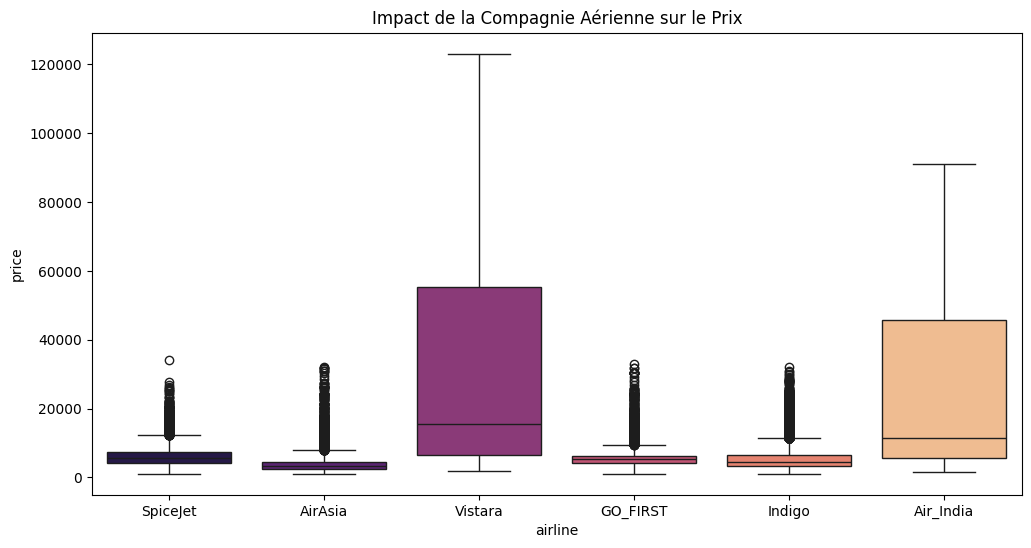

Interprétation: 
 Vistara et Air_India, qui sont les compagnies les plus fréquentes, montrent une large gamme de prix, incluant des billets très chers (Business). 
 Les autres compagnies, moins représentées, ont des prix plus concentrés dans la gamme économique. 
 Cela suggère que Vistara et Air_India offrent à la fois des options économiques et premium, tandis que les autres se concentrent principalement sur l'économie.


In [21]:
# 1. Compagnie Aérienne vs Prix
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='airline', y='price', hue='airline', palette='magma', legend=False)
plt.title("Impact de la Compagnie Aérienne sur le Prix")
plt.show()

print(f"Interprétation: \n Vistara et Air_India, qui sont les compagnies les plus fréquentes, montrent une large gamme de prix, incluant des billets très chers (Business). \n Les autres compagnies, moins représentées, ont des prix plus concentrés dans la gamme économique. \n Cela suggère que Vistara et Air_India offrent à la fois des options économiques et premium, tandis que les autres se concentrent principalement sur l'économie.")

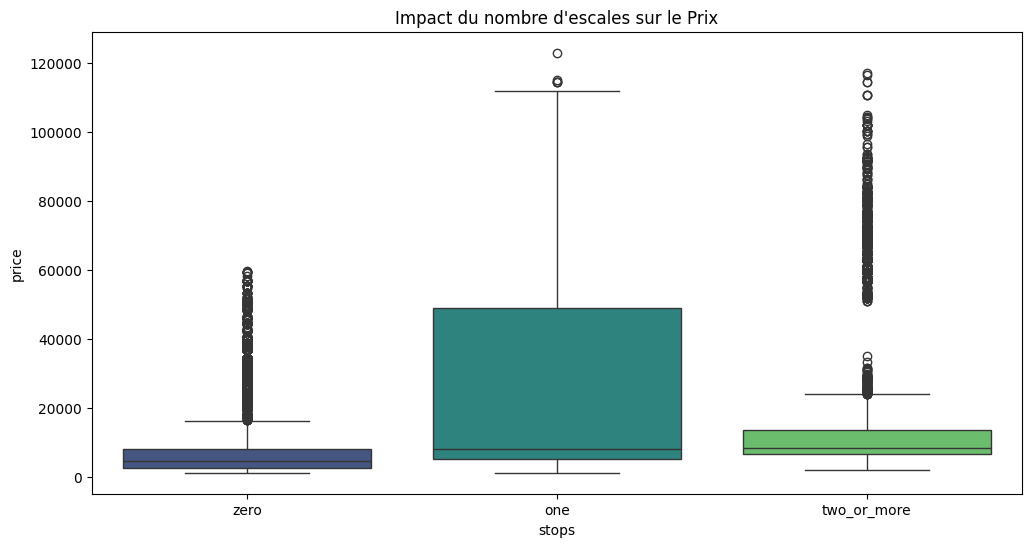

Interprétation :
Les vols avec une escale (one) sont souvent plus chers que les vols directs (zero), ce qui peut s'expliquer par des itinéraires plus longs ou des services supplémentaires. 
Cependant, les vols avec deux escales ou plus (two_or_more) ne sont pas systématiquement plus chers que ceux avec une seule escale, ce qui suggère que d'autres facteurs (comme la compagnie aérienne ou la classe de service) peuvent influencer le prix au-delà du simple nombre d'escales.


In [22]:
# 2. Nombre d’escales vs Prix (Est-ce qu'un trajet plus complexe coûte plus cher ?)
plt.figure(figsize=(12, 6))
# On ordonne les escales logiquement : 0, 1, puis 2+
stop_order = ['zero', 'one', 'two_or_more']
sns.boxplot(data=df, x='stops', y='price', 
            order=stop_order, palette='viridis', hue='stops', legend=False)
plt.title("Impact du nombre d'escales sur le Prix")
plt.show()

print(f"Interprétation :\nLes vols avec une escale (one) sont souvent plus chers que les vols directs (zero), ce qui peut s'expliquer par des itinéraires plus longs ou des services supplémentaires. \nCependant, les vols avec deux escales ou plus (two_or_more) ne sont pas systématiquement plus chers que ceux avec une seule escale, ce qui suggère que d'autres facteurs (comme la compagnie aérienne ou la classe de service) peuvent influencer le prix au-delà du simple nombre d'escales.")

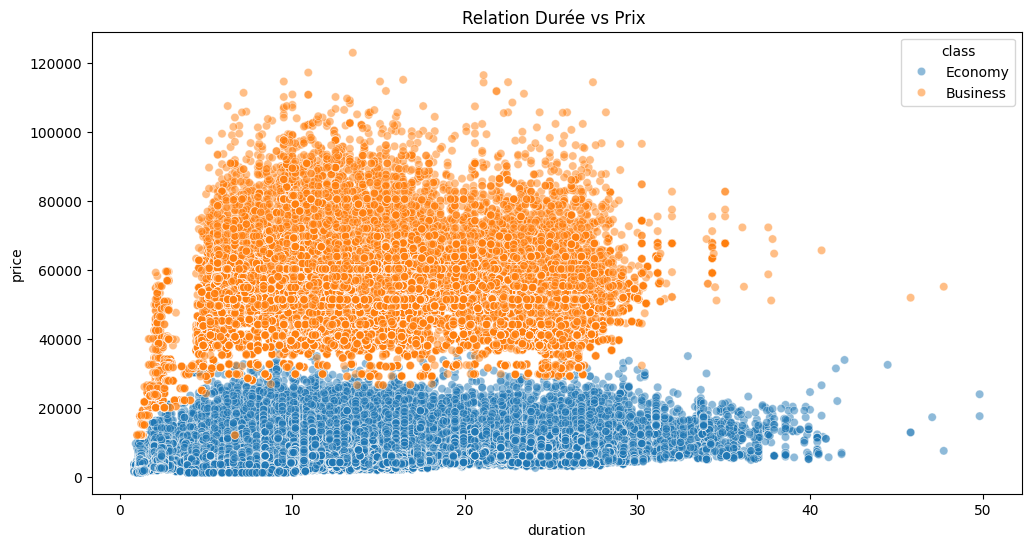

Interprétation :
Il existe une tendance générale à la hausse du prix avec la durée, mais elle est loin d'être linéaire. 
Les billets en classe Business (points orange) sont souvent beaucoup plus chers que les billets en classe Économie (points bleus) pour une même durée, ce qui indique que la classe de service est un facteur clé dans la détermination du prix, au-delà de la simple durée du vol. 
De plus, certains vols très longs restent relativement abordables, suggérant que d'autres facteurs (comme les escales ou la compagnie aérienne) peuvent également influencer le prix.


In [23]:
# 3. Durée du vol vs Prix
plt.figure(figsize=(12, 6))
# Multivariate : Duration vs Price + Distinction de la Classe
sns.scatterplot(data=df, x='duration', y='price', hue='class', alpha=0.5)
plt.title("Relation Durée vs Prix ")
plt.show()

print(f"Interprétation :\nIl existe une tendance générale à la hausse du prix avec la durée, mais elle est loin d'être linéaire. \nLes billets en classe Business (points orange) sont souvent beaucoup plus chers que les billets en classe Économie (points bleus) pour une même durée, ce qui indique que la classe de service est un facteur clé dans la détermination du prix, au-delà de la simple durée du vol. \nDe plus, certains vols très longs restent relativement abordables, suggérant que d'autres facteurs (comme les escales ou la compagnie aérienne) peuvent également influencer le prix.")

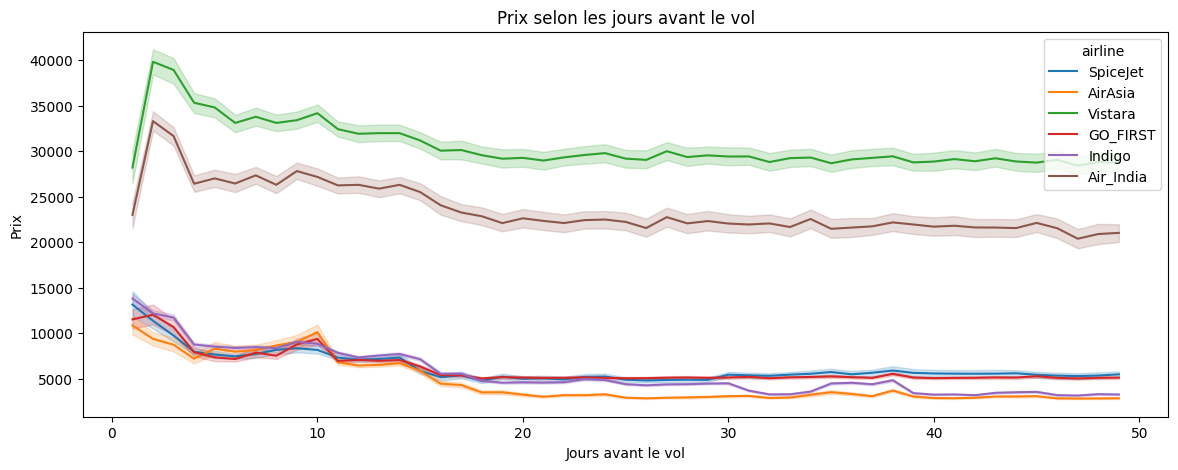

Interprétation :
Il y a une tendance générale à l'augmentation du prix à mesure que la date du vol approche (days_left diminue), ce qui est typique de la tarification de dernière minute. 
Cependant, cette tendance n'est pas uniforme pour toutes les compagnies aériennes : certaines (comme Vistara) montrent une augmentation plus marquée des prix à l'approche du vol, tandis que d'autres (comme Air_India) ont des prix plus stables, suggérant des stratégies de tarification différentes entre les compagnies.


In [24]:
#4. Jours avant vol (days_left) vs Prix
plt.figure(figsize=(14,5))
sns.lineplot(x='days_left', y='price', data=df, hue= 'airline' )

plt.title('Prix selon les jours avant le vol')
plt.xlabel('Jours avant le vol')
plt.ylabel('Prix')
plt.show()

print(f"Interprétation :\nIl y a une tendance générale à l'augmentation du prix à mesure que la date du vol approche (days_left diminue), ce qui est typique de la tarification de dernière minute. \nCependant, cette tendance n'est pas uniforme pour toutes les compagnies aériennes : certaines (comme Vistara) montrent une augmentation plus marquée des prix à l'approche du vol, tandis que d'autres (comme Air_India) ont des prix plus stables, suggérant des stratégies de tarification différentes entre les compagnies.")